# KR3 음식점 리뷰 감성분석 — BoW / TF-IDF / SBERT 비교
**오늘 할 일**
1. 텍스트를 숫자로 바꾸는 세 가지 방법을 배운다: **BoW → TF-IDF → SBERT**
2. 어떤 방법이 부정 리뷰를 제일 잘 찾는지 비교한다
3. 내가 만든 문장을 직접 넣어보며 모델별 특징을 비교해본다
4. 팀별로 문장을 만들어 모델을 속여보자

---
## 1. 준비

In [1]:
!pip install -q datasets sentence-transformers

In [4]:
import warnings, re, random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from datasets import load_dataset
from sentence_transformers import SentenceTransformer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('환경 준비 완료')

환경 준비 완료


---
## 2. 몸풀기 — 텍스트를 숫자로

이론에서 배웠듯이 컴퓨터는 글자를 모릅니다. 그래서 "**단어를 세서 숫자 목록(벡터)을 만들고, 벡터끼리 비교한다**"가
오늘 배울 모든 방법(BoW, TF-IDF, SBERT)의 공통 뼈대입니다. 손으로 한 번 만들어 봅시다.

In [5]:
sentences = ["나는 강아지를 좋아한다", "나는 고양이를 좋아한다", "오늘 날씨가 정말 좋다"]

print("── 토큰화 ──")
for s in sentences:
    print(f"{s}  →  {s.split()}")
print()

vocab = sorted(set(w for s in sentences for w in s.split()))
print("사전:", vocab)
print()

def to_vec(s, vocab):
    return np.array([s.split().count(w) for w in vocab])
vectors = [to_vec(s, vocab) for s in sentences]

display(pd.DataFrame(vectors, columns=vocab, index=sentences))

# : 유사도 비교 (겹치는 단어가 많을수록 1에 가까움)
print(f"'{sentences[0]}' vs '{sentences[1]}' → {cosine_similarity([vectors[0]],[vectors[1]])[0][0]:.3f}  (겹치는 단어 있음)")
print(f"'{sentences[0]}' vs '{sentences[2]}' → {cosine_similarity([vectors[0]],[vectors[2]])[0][0]:.3f}  (겹치는 단어 없음)")

── 토큰화 ──
나는 강아지를 좋아한다  →  ['나는', '강아지를', '좋아한다']
나는 고양이를 좋아한다  →  ['나는', '고양이를', '좋아한다']
오늘 날씨가 정말 좋다  →  ['오늘', '날씨가', '정말', '좋다']

사전: ['강아지를', '고양이를', '나는', '날씨가', '오늘', '정말', '좋다', '좋아한다']



,강아지를,고양이를,나는,날씨가,오늘,정말,좋다,좋아한다
나는 강아지를 좋아한다,1,0,1,0,0,0,0,1
나는 고양이를 좋아한다,0,1,1,0,0,0,0,1
오늘 날씨가 정말 좋다,0,0,0,1,1,1,1,0


'나는 강아지를 좋아한다' vs '나는 고양이를 좋아한다' → 0.667  (겹치는 단어 있음)
'나는 강아지를 좋아한다' vs '오늘 날씨가 정말 좋다' → 0.000  (겹치는 단어 없음)


In [6]:
s_a = "정말 정말 맛있다"
s_b = "정말 별로다"

def bow_sim(s1, s2):
    voc = sorted(set(s1.split()) | set(s2.split()))
    v1, v2 = to_vec(s1, voc), to_vec(s2, voc)
    return cosine_similarity([v1], [v2])[0][0]

print(f"불용어 제거 전: '{s_a}' vs '{s_b}'  →  {bow_sim(s_a, s_b):.3f}")

stopwords = {'정말'}
remove_sw = lambda s: ' '.join(w for w in s.split() if w not in stopwords)
sa2, sb2 = remove_sw(s_a), remove_sw(s_b)
print(f"불용어 제거 후: '{sa2}' vs '{sb2}'  →  {bow_sim(sa2, sb2):.3f}")

불용어 제거 전: '정말 정말 맛있다' vs '정말 별로다'  →  0.632
불용어 제거 후: '맛있다' vs '별로다'  →  0.000


---
## 3. 데이터 불러오기

**KR3**: 한국어 식당 리뷰 + 감성 라벨 (`0`=부정, `1`=긍정, `2`=모호). 모호(2)는 제외합니다.

In [7]:
kr3 = load_dataset("leey4n/KR3", name="default", split="train")
kr3 = kr3.filter(lambda x: x['Rating'] != 2)

df = kr3.to_pandas().rename(columns={'Rating':'label', 'Review':'document'})
df = df[['label','document']].dropna().drop_duplicates(subset='document').reset_index(drop=True)

print(df.shape)
df.head(3)

README.md:   0%|          | 0.00/2.40k [00:00<?, ?B/s]

kr3.parquet: reconstructing file:   0%|          |  0.00B /  120MB            

kr3.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/641762 [00:00<?, ? examples/s]

Filter:   0%|          | 0/641762 [00:00<?, ? examples/s]

(457629, 2)


,label,document
0,1,숙성 돼지고기 전문점입니다. 건물 모양 때문에 매장 모양도 좀 특이하지만 쾌적한 편...
1,1,고기가 정말 맛있었어요! 육즙이 가득 있어서 너무 좋았아요 일하시는 분들 너무 친절...
2,1,"잡내 없고 깔끔, 담백한 맛의 순댓국이 순댓국을 안 좋아하는 사람들에게도 술술 넘어..."


---
## 4. EDA — 불균형 확인

label
1    0.845
0    0.155
Name: proportion, dtype: float64


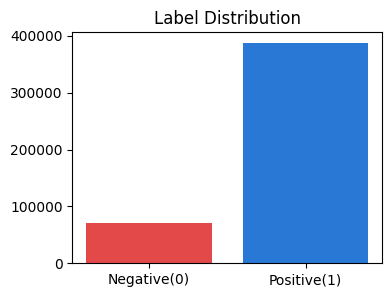

In [8]:
counts = df['label'].value_counts().sort_index()
print(df['label'].value_counts(normalize=True).round(3))

plt.figure(figsize=(4,3))
plt.bar(['Negative(0)','Positive(1)'], counts.values, color=['#e34948','#2a78d6'])
plt.title('Label Distribution')
plt.show()

---
## 5. 왜 정확도 대신 부정 F1?

전부 "긍정"이라고 찍으면?

In [9]:
pos = np.ones(len(df), dtype=int)
print(f"정확도    : {accuracy_score(df['label'], pos):.3f}")
print(f"부정(0) F1: {f1_score(df['label'], pos, pos_label=0):.3f}")
# 정확도는 85%인데 부정은 단 한 건도 못 찾았습니다 → 그래서 오늘은 부정 F1을 봅니다.

정확도    : 0.845
부정(0) F1: 0.000


---
## 6. 학습/평가 분할 + 공통 평가 함수

실습에서는 학습/평가를 가볍게 하기 위해 학습 5,000 / 평가 1,000건만 씁니다
(정석대로면 데이터가 많은 것이 좋지만, 오늘 목표는 세 방법의 흐름을 비교하는 것입니다).

In [10]:
TRAIN_SIZE, TEST_SIZE = 5000, 1000
sample, _ = train_test_split(df, train_size=TRAIN_SIZE+TEST_SIZE, stratify=df['label'], random_state=SEED)
train_df, test_df = train_test_split(sample, test_size=TEST_SIZE, stratify=sample['label'], random_state=SEED)
train_df, test_df = train_df.reset_index(drop=True), test_df.reset_index(drop=True)

X_train, y_train = train_df['document'], train_df['label']
X_test,  y_test  = test_df['document'],  test_df['label']
print(f"train {len(train_df):,} / test {len(test_df):,}")

train 5,000 / test 1,000


In [11]:
# pos_label ??
log = []
def evaluate(name, y_pred):
    f1  = f1_score(y_test, y_pred, pos_label=0)
    pre = precision_score(y_test, y_pred, pos_label=0, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=0)
    print(f"[{name}] 부정 F1 {f1:.4f} | Precision {pre:.4f} | Recall {rec:.4f}")
    log.append({'방법': name, '부정 F1': round(f1,4), 'Precision': round(pre,4), 'Recall': round(rec,4)})
    return f1
print('평가 함수 준비 완료')

평가 함수 준비 완료


In [12]:
# 그대로 실행
def predict_one(name, vectorize_fn, clf, text):
    v = vectorize_fn([text])
    pred, proba = clf.predict(v)[0], clf.predict_proba(v)[0]
    return {'모델': name, '예측': '부정' if pred==0 else '긍정', '확신도': f"{max(proba)*100:.1f}%"}

def sim_one(name, vectorize_fn, t1, t2):
    sim = cosine_similarity(vectorize_fn([t1]), vectorize_fn([t2]))[0][0]
    return {'모델': name, '유사도': round(float(sim), 4)}

def quick_test(name, vectorize_fn, clf, text, pair):
    r = predict_one(name, vectorize_fn, clf, text)
    print(f"[{name}] 예측 : '{text}' → {r['예측']} (확신도 {r['확신도']})")
    s = sim_one(name, vectorize_fn, *pair)
    print(f"[{name}] 유사도: '{pair[0]}' vs '{pair[1]}' → {s['유사도']:.3f}")

print('테스트 함수 준비')

테스트 함수 준비


---
## 7. 방법① BoW

In [13]:
# Char BoW: 한국어 리뷰의 어미 변화와 띄어쓰기 문제를 고려한 기본 BoW 방식
bow = CountVectorizer(analyzer='char', ngram_range=(1,3), max_features=8000)
Xtr_bow = bow.fit_transform(X_train)
Xte_bow = bow.transform(X_test)   # train만 fit! test는 변환만
print('BoW 벡터 크기:', Xtr_bow.shape)

BoW 벡터 크기: (5000, 8000)


In [14]:
# 지금 만든 bow가 실제로 이 문장을 어떻게 잘라내는지 확인
analyze = bow.build_analyzer()
print(analyze("맛있어요"))

['맛', '있', '어', '요', '맛있', '있어', '어요', '맛있어', '있어요']


In [15]:
demo_reviews = [
    "여기 진짜 맛있어요",
    "다시는 안 가요",
    "친절하고 좋아요",
    "너무 비싸고 별로예요",
    "완전 최고예요"
]

demo_bow = CountVectorizer(
    analyzer='char',
    ngram_range=(1, 3),
    max_features=15
)

demo_matrix = demo_bow.fit_transform(demo_reviews)

# 공백은 표에서 잘 안 보이기 때문에 ␣로 바꿔서 표시
bow_display_cols = [
    c.replace(" ", "␣")
    for c in demo_bow.get_feature_names_out()
]

print(
    "char 예시 행렬 크기:",
    demo_matrix.shape,
    "(실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)"
)

display(pd.DataFrame(
    demo_matrix.toarray(),
    columns=bow_display_cols,
    index=demo_reviews
))

char 예시 행렬 크기: (5, 15) (실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)


,␣,␣가,␣가요,␣맛있,␣별,␣비싸,␣안,␣안␣,␣좋,␣좋아,고,고␣,예,예요,요
여기 진짜 맛있어요,2,0,0,1,0,0,0,0,0,0,0,0,0,0,1
다시는 안 가요,2,1,1,0,0,0,1,1,0,0,0,0,0,0,1
친절하고 좋아요,1,0,0,0,0,0,0,0,1,1,1,1,0,0,1
너무 비싸고 별로예요,2,0,0,0,1,1,0,0,0,0,1,1,1,1,1
완전 최고예요,1,0,0,0,0,0,0,0,0,0,1,0,1,1,1


In [16]:
demo_reviews = [
    "여기 진짜 맛있어요",
    "다시는 안 가요",
    "친절하고 좋아요",
    "너무 비싸고 별로예요",
    "완전 최고예요"
]

demo_word_bow = CountVectorizer(
    analyzer='word',
    ngram_range=(1, 2),          # 단어 1개, 2개 묶음까지
    max_features=15,
    token_pattern=r"(?u)\b\w+\b" # 한 글자 단어도 포함
)

demo_word_matrix = demo_word_bow.fit_transform(demo_reviews)

print(
    "word 예시 행렬 크기:",
    demo_word_matrix.shape,
    "(실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)"
)

display(pd.DataFrame(
    demo_word_matrix.toarray(),
    columns=demo_word_bow.get_feature_names_out(),
    index=demo_reviews
))

word 예시 행렬 크기: (5, 15) (실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)


,가요,너무,너무 비싸고,다시는,다시는 안,맛있어요,별로예요,비싸고,비싸고 별로예요,안,안 가요,여기,여기 진짜,완전,완전 최고예요
여기 진짜 맛있어요,0,0,0,0,0,1,0,0,0,0,0,1,1,0,0
다시는 안 가요,1,0,0,1,1,0,0,0,0,1,1,0,0,0,0
친절하고 좋아요,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
너무 비싸고 별로예요,0,1,1,0,0,0,1,1,1,0,0,0,0,0,0
완전 최고예요,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1


In [17]:
clf_bow = LogisticRegression(max_iter=1000, class_weight='balanced')   # balanced: 적은 부정 클래스를 더 신경써서 학습
clf_bow.fit(Xtr_bow, y_train)
evaluate('1. BoW', clf_bow.predict(Xte_bow))

[1. BoW] 부정 F1 0.7044 | Precision 0.6871 | Recall 0.7226


0.7044025157232704

In [20]:
# BoW 평가
text, pair = "신기한 맛이 나요", ("아름다워요", "예뻐요")   # 여기서 바꿔보세요
quick_test('BoW', lambda t: bow.transform(t), clf_bow, text, pair)

[BoW] 예측 : '신기한 맛이 나요' → 긍정 (확신도 55.6%)
[BoW] 유사도: '아름다워요' vs '예뻐요' → 0.236


---
## 8. 방법② TF-IDF

In [21]:
# Char TF-IDF: 한국어 리뷰에 더 안정적인 기본 TF-IDF 방식
tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(1, 3),
    max_features=8000
)

Xtr_tf = tfidf.fit_transform(X_train)
Xte_tf = tfidf.transform(X_test)

print("Char TF-IDF 벡터 크기:", Xtr_tf.shape)

Char TF-IDF 벡터 크기: (5000, 8000)


In [22]:
demo_reviews = [
    "여기 진짜 맛있어요",
    "다시는 안 가요",
    "친절하고 좋아요",
    "너무 비싸고 별로예요",
    "완전 최고예요"
]

demo_char_tfidf = TfidfVectorizer(
    analyzer='char',
    ngram_range=(1, 3),
    max_features=15
)

demo_char_matrix = demo_char_tfidf.fit_transform(demo_reviews)

# 공백을 눈에 보이게 표시
char_display_cols = [
    c.replace(" ", "␣")
    for c in demo_char_tfidf.get_feature_names_out()
]

print(
    "Char TF-IDF 예시 행렬 크기:",
    demo_char_matrix.shape,
    "(실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)"
)

display(pd.DataFrame(
    demo_char_matrix.toarray().round(3),
    columns=char_display_cols,
    index=demo_reviews
))

Char TF-IDF 예시 행렬 크기: (5, 15) (실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)


,␣,␣가,␣가요,␣맛있,␣별,␣비싸,␣안,␣안␣,␣좋,␣좋아,고,고␣,예,예요,요
여기 진짜 맛있어요,0.652,0.000,0.000,0.684,0.000,0.000,0.000,0.000,0.00,0.00,0.000,0.000,0.000,0.000,0.326
다시는 안 가요,0.421,0.441,0.441,0.000,0.000,0.000,0.441,0.441,0.00,0.00,0.000,0.000,0.000,0.000,0.210
친절하고 좋아요,0.253,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.53,0.53,0.355,0.428,0.000,0.000,0.253
너무 비싸고 별로예요,0.405,0.000,0.000,0.000,0.425,0.425,0.000,0.000,0.00,0.00,0.285,0.343,0.343,0.343,0.203
완전 최고예요,0.321,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.00,0.00,0.451,0.000,0.543,0.543,0.321


In [23]:
demo_reviews = [
    "여기 진짜 맛있어요",
    "다시는 안 가요",
    "친절하고 좋아요",
    "너무 비싸고 별로예요",
    "완전 최고예요"
]

demo_word_tfidf = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    max_features=15,
    token_pattern=r"(?u)\b\w+\b"
)

demo_word_matrix = demo_word_tfidf.fit_transform(demo_reviews)

print(
    "Word TF-IDF 예시 행렬 크기:",
    demo_word_matrix.shape,
    "(실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)"
)

display(pd.DataFrame(
    demo_word_matrix.toarray().round(3),
    columns=demo_word_tfidf.get_feature_names_out(),
    index=demo_reviews
))

Word TF-IDF 예시 행렬 크기: (5, 15) (실제 모델은 위에서 5,000행 × 8,000열로 학습합니다)


,가요,너무,너무 비싸고,다시는,다시는 안,맛있어요,별로예요,비싸고,비싸고 별로예요,안,안 가요,여기,여기 진짜,완전,완전 최고예요
여기 진짜 맛있어요,0.000,0.000,0.000,0.000,0.000,0.577,0.000,0.000,0.000,0.000,0.000,0.577,0.577,0.000,0.000
다시는 안 가요,0.447,0.000,0.000,0.447,0.447,0.000,0.000,0.000,0.000,0.447,0.447,0.000,0.000,0.000,0.000
친절하고 좋아요,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
너무 비싸고 별로예요,0.000,0.447,0.447,0.000,0.000,0.000,0.447,0.447,0.447,0.000,0.000,0.000,0.000,0.000,0.000
완전 최고예요,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.707,0.707


In [24]:
clf_tf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_tf.fit(Xtr_tf, y_train)

evaluate('2. TF-IDF (Char)', clf_tf.predict(Xte_tf))

[2. TF-IDF (Char)] 부정 F1 0.7444 | Precision 0.6537 | Recall 0.8645


0.7444444444444445

In [27]:
# TF-IDF 평가
text, pair = "너무 맛이 없어요", ("싫다", "좋아요")   # 여기서 바꿔보세요
quick_test('TF-IDF', lambda t: tfidf.transform(t), clf_tf, text, pair)

[TF-IDF] 예측 : '너무 맛이 없어요' → 부정 (확신도 81.2%)
[TF-IDF] 유사도: '싫다' vs '좋아요' → 0.000


---
## 9. 방법③ SBERT

> 6,000문장 기준 GPU면 1분 내외, CPU면 수 분 정도 걸립니다 (하드웨어에 따라 다름 — 없어도 그냥 기다리면 됩니다).
> Colab이고 너무 느리면 [런타임] → [런타임 유형 변경] → GPU로 바꾼 뒤 처음부터 다시 실행하세요.

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

sbert = SentenceTransformer('jhgan/ko-sroberta-multitask', device=device)
Xtr_s = sbert.encode(X_train.tolist(), batch_size=128, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
Xte_s = sbert.encode(X_test.tolist(),  batch_size=128, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
print('SBERT 벡터 크기:', Xtr_s.shape)

device: cuda


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/4.86k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Batches:   0%|          | 0/8 [00:00<?, ?it/s]

SBERT 벡터 크기: (5000, 768)


In [29]:
review_idx = 0

print("리뷰 원문:")
print(X_train.iloc[review_idx] if hasattr(X_train, "iloc") else X_train[review_idx])
print()

print("SBERT 벡터 크기:", Xtr_s[review_idx].shape)
print("앞 20개 값:")
print(Xtr_s[review_idx][:20])

리뷰 원문:
칼국수 보쌈이 일품이다 칼국수 보쌈의 맛 중 반은 김치라고 생각하는데 김치가 정말 맛있다 구성비 굿굿굿

SBERT 벡터 크기: (768,)
앞 20개 값:
[-0.01193099  0.02126097 -0.06491034 -0.03314391 -0.01961269  0.01623395
 -0.0163139  -0.02208136 -0.00252661 -0.04777626  0.05301173  0.02842853
  0.02725178 -0.05130709  0.04003466 -0.00360086  0.02246295  0.03709171
  0.00034254 -0.03486736]


In [30]:
demo_reviews = [
    "여기 진짜 맛있어요",
    "다시는 안 가요",
    "친절하고 좋아요",
    "너무 비싸고 별로예요",
    "완전 최고예요"
]

demo_sbert_matrix = sbert.encode(
    demo_reviews,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print(
    "SBERT 예시 벡터 크기:",
    demo_sbert_matrix.shape,
    "(문장 5개 × 768차원 의미 벡터)"
)

display(pd.DataFrame(
    demo_sbert_matrix[:, :20].round(4),  # 총 768차원이지만 앞 20개 차원만 표시
    columns=[f"dim_{i}" for i in range(20)],
    index=demo_reviews
))

SBERT 예시 벡터 크기: (5, 768) (문장 5개 × 768차원 의미 벡터)


,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,dim_10,dim_11,dim_12,dim_13,dim_14,dim_15,dim_16,dim_17,dim_18,dim_19
여기 진짜 맛있어요,-0.0074,0.0110,-0.0048,-0.0108,-0.0257,-0.0030,0.0142,-0.0180,0.0338,-0.0487,0.0058,-0.0519,-0.0219,-0.0347,0.0123,-0.0029,-0.0240,-0.0095,0.0125,-0.0064
다시는 안 가요,-0.0038,-0.0358,-0.0121,-0.0232,-0.0333,-0.0568,0.0058,0.0020,0.0552,-0.0545,-0.0102,-0.0321,-0.0125,-0.0097,-0.0366,-0.0235,-0.0254,-0.0096,-0.0172,-0.0512
친절하고 좋아요,-0.0317,-0.0023,-0.0450,0.0666,0.0326,-0.0368,0.0313,0.0298,0.0679,-0.0070,-0.0254,-0.0926,-0.0395,0.0507,0.0578,0.0225,-0.0131,0.0073,0.0125,-0.0233
너무 비싸고 별로예요,-0.0006,-0.0582,0.0275,0.0387,0.0140,-0.0101,0.0135,0.0580,0.0327,-0.0464,0.0357,-0.0160,-0.0035,0.0354,-0.0473,0.0340,0.0444,-0.0345,0.0042,-0.0353
완전 최고예요,-0.0204,0.0041,0.0097,0.0086,-0.0168,-0.0483,-0.0320,-0.0186,0.0785,-0.0192,0.0245,-0.1164,0.0054,-0.0206,0.0418,-0.0423,0.0169,0.0015,0.0072,-0.0003


In [31]:
demo_sbert_sim = cosine_similarity(demo_sbert_matrix)

display(pd.DataFrame(
    demo_sbert_sim.round(3),
    index=demo_reviews,
    columns=demo_reviews
))

,여기 진짜 맛있어요,다시는 안 가요,친절하고 좋아요,너무 비싸고 별로예요,완전 최고예요
여기 진짜 맛있어요,1.000,0.217,0.460,0.250,0.616
다시는 안 가요,0.217,1.000,0.204,0.210,0.219
친절하고 좋아요,0.460,0.204,1.000,0.152,0.550
너무 비싸고 별로예요,0.250,0.210,0.152,1.000,0.279
완전 최고예요,0.616,0.219,0.550,0.279,1.000


In [32]:
clf_s = LogisticRegression(max_iter=1000, class_weight='balanced')
clf_s.fit(Xtr_s, y_train)
evaluate('3. SBERT', clf_s.predict(Xte_s))
sbert_vec = lambda t: sbert.encode(t, convert_to_numpy=True, normalize_embeddings=True)

[3. SBERT] 부정 F1 0.8159 | Precision 0.7273 | Recall 0.9290


In [33]:
# SBERT 평가
text, pair = "제 입맛에는 맞지 않아요", ("뷰티풀", "아름다워")   # 여기서 바꿔보세요
quick_test('SBERT', sbert_vec, clf_s, text, pair)
# 해보진 않았는데 성능 차이가 날수도있다 char, 단어 기반 방식따라

[SBERT] 예측 : '제 입맛에는 맞지 않아요' → 부정 (확신도 92.0%)
[SBERT] 유사도: '뷰티풀' vs '아름다워' → 0.649


---
## 10. 모델 비교


,방법,부정 F1,Precision,Recall
2,3. SBERT,0.8159,0.7273,0.9290
1,2. TF-IDF (Char),0.7444,0.6537,0.8645
0,1. BoW,0.7044,0.6871,0.7226


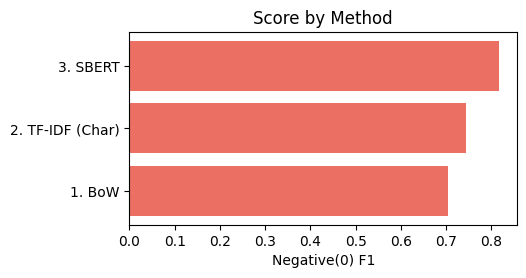

In [34]:
res = pd.DataFrame(log).drop_duplicates(subset='방법', keep='last').sort_values('부정 F1', ascending=False)
display(res)

plt.figure(figsize=(5,2.5))
plt.barh(res['방법'], res['부정 F1'], color='#e74c3c', alpha=.8)
plt.xlabel('Negative(0) F1')
plt.gca().invert_yaxis()
plt.title('Score by Method')
plt.show()

### 모델별로 비슷한 리뷰 검색하기

In [35]:
def find_similar_reviews(query, top_n=3):
    searches = [
        ('BoW',    lambda t: bow.transform(t),   Xtr_bow),
        ('TF-IDF', lambda t: tfidf.transform(t), Xtr_tf),
        ('SBERT',  sbert_vec,                    Xtr_s),
    ]
    for name, vec_fn, corpus in searches:
        sims = cosine_similarity(vec_fn([query]), corpus).ravel()
        top_idx = sims.argsort()[::-1][:top_n]
        print(f"── {name} 기준 가장 비슷한 리뷰 ──")
        for i in top_idx:
            print(f"  [{sims[i]:.3f}] {train_df['document'].iloc[i][:70]}")
        print()

find_similar_reviews('된장찌개 맛집 추천 부탁드립니다')

── BoW 기준 가장 비슷한 리뷰 ──
  [0.534] 중문 맛집 중 최고입니다. 우럭이 이렇게 맛있다는 건 처음 알았네요. 추천드립니다.
  [0.506] 여기는 제 인생 주꾸미입니다.. 주꾸미 좋아하시면 여기는 꼭꼭 가세용  그리고 볶음밥 진짜 너무 맛있어요!!!! 국물 조금 적
  [0.498] 잘 먹자 어찌 됐든 밥 챙겨 먹자. 그저 사는 게 아닌 잘 먹는 것이 잘 삶이다. 때론 밥 먹자 한마디가 위로다. 힘내자 토요

── TF-IDF 기준 가장 비슷한 리뷰 ──
  [0.502] 된장찌개 최고존엄..
  [0.354] 비립니다
  [0.340] 중문 맛집 중 최고입니다. 우럭이 이렇게 맛있다는 건 처음 알았네요. 추천드립니다.

── SBERT 기준 가장 비슷한 리뷰 ──
  [0.683] 된장찌개 최고존엄..
  [0.659] 맛남 저렴이, 밥이 시의 한 수 우렁이 된장 추천!
  [0.630] 와 여기 찌개 맛있어요. 밑반찬도 맛있고 숭늉도 있어요! 다른 메뉴도 궁금해요. 그리고 간판이 바뀌었어요



---
## 11. 팀과제


In [41]:
# 겉보기엔 별점5점 같지만 실제로는 불만인 리뷰로 세 모델을 속여보자
# 이 리스트에 든 문장의 "진짜 감정"은 전부 부정입니다. 모델이 긍정으로 답하면 속은 겁니다.
# 세 모델 각각 속은 이유가 무엇일지 이유를 생각해보자.
# 모델별 특성에 기반한 속은 이유 도출해보기

MODELS = [
    ('BoW',    lambda t: bow.transform(t),   clf_bow),
    ('TF-IDF', lambda t: tfidf.transform(t), clf_tf),
    ('SBERT',  sbert_vec,                    clf_s),
]

team_quiz = [
    # (문장, 유형)
    ("느좋", "신조어"),
    ("참 잘도 만들었네요", "비꼬기"),
    ("아주 훌륭한 경험이었어요", "맥락형 반어"),
    ("덕분에 좋은 경험 했습니다", "감사형 반어"),
    ("여기 정말 대단하네요", "칭찬형 비꼬기"),
    ("기억에 오래 남겠어요", "완곡한 불만"),
    ("상상 이상의 맛이네요", "중의적 반어"),
    ("말이 필요 없는 맛입니다", "중의적 반어"),
    ("쉽게 잊히지 않을 것 같아요", "완곡한 불만"),
    ("이걸 먹으러 여기까지 오다니", "비꼬기"),
    ("뭔가 고차원적인 맛이에요", "중의적 반어")
    # 팀원당 2~3개씩 추가해서 채워보세요
]

rows = []
for text, category in team_quiz:
    row = {'문장': text, '유형': category}
    fooled = 0
    for name, vec_fn, clf in MODELS:
        pred = clf.predict(vec_fn([text]))[0]
        pred_label = '부정' if pred == 0 else '긍정'
        row[name] = pred_label
        if pred_label == '긍정':   # 정답은 항상 부정 → 긍정으로 답하면 속은 것
            fooled += 1
    row['속인 모델 수'] = fooled
    rows.append(row)

quiz_df = pd.DataFrame(rows)
display(quiz_df.sort_values('속인 모델 수', ascending=False))

print(f"\n세 모델을 전부 속인 문장: {(quiz_df['속인 모델 수']==3).sum()} / {len(quiz_df)}개")
print(quiz_df[quiz_df['속인 모델 수']==3][['문장','유형']].to_string(index=False))

,문장,유형,BoW,TF-IDF,SBERT,속인 모델 수
0,느좋,신조어,긍정,긍정,긍정,3
1,참 잘도 만들었네요,비꼬기,긍정,긍정,긍정,3
2,아주 훌륭한 경험이었어요,맥락형 반어,긍정,긍정,긍정,3
3,덕분에 좋은 경험 했습니다,감사형 반어,긍정,긍정,긍정,3
4,여기 정말 대단하네요,칭찬형 비꼬기,긍정,긍정,긍정,3
5,기억에 오래 남겠어요,완곡한 불만,긍정,긍정,긍정,3
6,상상 이상의 맛이네요,중의적 반어,긍정,긍정,긍정,3
7,말이 필요 없는 맛입니다,중의적 반어,긍정,긍정,긍정,3
8,쉽게 잊히지 않을 것 같아요,완곡한 불만,긍정,긍정,긍정,3
9,이걸 먹으러 여기까지 오다니,비꼬기,긍정,긍정,긍정,3



세 모델을 전부 속인 문장: 11 / 11개
             문장      유형
             느좋     신조어
     참 잘도 만들었네요     비꼬기
  아주 훌륭한 경험이었어요  맥락형 반어
 덕분에 좋은 경험 했습니다  감사형 반어
    여기 정말 대단하네요 칭찬형 비꼬기
    기억에 오래 남겠어요  완곡한 불만
    상상 이상의 맛이네요  중의적 반어
  말이 필요 없는 맛입니다  중의적 반어
쉽게 잊히지 않을 것 같아요  완곡한 불만
이걸 먹으러 여기까지 오다니     비꼬기
  뭔가 고차원적인 맛이에요  중의적 반어


In [42]:
# 우리 팀 검색어로 3가지 모델이 뭘 찾아오는지 비교
#

find_similar_reviews('친구들에게 꼭 추천하고 싶은 곳이에요')

# 검색어를 여러 번 바꿔가며 실행해서, 세 모델의 1등 리뷰가 전부 다르게 나오는 + 전부 잘 나오는
# 검색어를 각각 하나씩 찾아보시면 됩니다. 해당 리뷰를 발표.
# 모델당 3개씩 총 9개의 문장이 모두 적절한 리뷰가 찾아지는 검색어를 입력한 팀은 전원 제가 상품 드립니다.

── BoW 기준 가장 비슷한 리뷰 ──
  [0.584] 맛 집인 줄은 모른 채 친구와 전시를 보고 지나가다 들러서 사 먹었던 에그타르트. 폭신하고 따듯해서 맛있었어요! 에그타르트를 
  [0.578] 직원들 정말 불친절하고 주문 잘못 받고 30분 넘게 기다리게 하고 빌지 집어던지고 그릇 집어던지고 정말 다신 안 가고 싶은 곳
  [0.569] 서면에서 생선회, 스시 깔끔하고 맛있게 드시기에 추천하고픈 곳이에요 튀김 바삭바삭하니 항상 맛있어요굳굳

── TF-IDF 기준 가장 비슷한 리뷰 ──
  [0.344] 분위기도 좋고 맥주도 너무 맛있어요 자주 오고 싶은  곳이에요
  [0.289] 서면에서 생선회, 스시 깔끔하고 맛있게 드시기에 추천하고픈 곳이에요 튀김 바삭바삭하니 항상 맛있어요굳굳
  [0.262] 맛 집인 줄은 모른 채 친구와 전시를 보고 지나가다 들러서 사 먹었던 에그타르트. 폭신하고 따듯해서 맛있었어요! 에그타르트를 

── SBERT 기준 가장 비슷한 리뷰 ──
  [0.668] 친구들과 자주 가는 곳입니다 맛있어요! 가격도 합리적입니다
  [0.651] 친구들이랑 놀러 왔다가 와봤는데 양도 많고 굉장히 맛있네요. 다음에 올 때 또 올게요
  [0.598] 멀리서 찾아오긴 좀 그렇고 근처면 갈만하다 인테리어가 편안해서 친구랑 편하게 수다떨기 좋은 곳 늦게까지 한다는 것도 아주아주 



# ══════════════════════════════════════════════
# 발표에 들어갈 내용
# ══════════════════════════════════════════════

발표 가이드 (팀당 2분)
1. 우리 팀 문장 중 세 모델이 전부 다르게 답한 게 있나요? 어떤 문장이었나요?
2. 어느 모델이 우리 팀 문장에서 제일 많이 틀렸나요? 왜 그럴 것 같나요?
3. 유사도 대결에서 SBERT만 사람 판단과 같았던 쌍이 있나요?
4. 반대로 SBERT도 틀린 문장이 있었다면? (있다면 상품!)
5. 우리 팀이 고른 '유형'(반어법/신조어/오타 등) 중 어떤 유형이 모델을 제일 잘 속였나요?
